# Repayment model fairness audit

## Business use case

Credit models convert a probability estimate into a decision: approve or deny. That final decision rule matters as much as the predictive model itself because different groups can experience different error rates even when a protected attribute is excluded from training.

This notebook uses a German credit dataset to examine that problem in a controlled setting. A logistic regression estimates the probability that an applicant will repay. **Gender is deliberately excluded from the model formula** and retained only for the fairness audit.

## Principal objective

The objective is to build a repayment model, choose an operating threshold that achieves an overall true-positive rate of at least 60%, and then test whether that opportunity rate is distributed similarly across gender groups. The final section explores threshold adjustment as a fairness intervention and measures the trade-offs it creates.

The analysis is best read as an educational fairness audit rather than a production lending policy. In real credit decisions, the use of protected attributes or group-specific thresholds requires legal and compliance review.

## Step 1 — Set up the analysis

The workflow starts with the core libraries used for data preparation, modeling, evaluation, and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Step 2 — Load the credit data and create a holdout set

The dataset contains applicant financial and demographic information together with the target variable `repay`. The notebook uses a 70/30 train-test split with a fixed random state so the saved experiment is reproducible.

A key design choice is to keep `Gender` in the dataframe for auditing while excluding it from the predictive formula. This separates **model input** from **fairness evaluation**: the protected attribute is not used to generate the repayment probability, but it remains available to check whether outcomes differ across groups.

In [2]:
df = pd.read_csv("/data/german_credit.csv")

In [3]:
df.head()

,Account_status,Duration,Credit_history,Purpose,Amount,Savings,Employment,Installment_rate,Guarantors,Resident_since,...,Age,Other_plans,Housing,Num_credits,Job,People_maintenance,Phone,Foreign,Gender,repay
0,< 0 DM,6,critical account / other credits existing (not...,radio / television,1169,unknown / no savings account,>= 7 years,4,none,4,...,67,none,A152,2,skilled employee / official,1,"yes, registered under the customers name",yes,Female,1
1,0 < ... < 200 DM,48,existing credits paid back duly till now,radio / television,5951,< 100 DM,1 <= ... < 4 years,2,none,2,...,22,none,A152,1,skilled employee / official,1,none,yes,Male,0
2,no checking account,12,critical account / other credits existing (not...,education,2096,< 100 DM,4 <= ... < 7 years,2,none,3,...,49,none,A152,1,unskilled - resident,2,none,yes,Female,1
3,< 0 DM,42,existing credits paid back duly till now,furniture / equipment,7882,< 100 DM,4 <= ... < 7 years,2,guarantor,4,...,45,none,A153,1,skilled employee / official,2,none,yes,Female,1
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 <= ... < 4 years,3,none,4,...,53,none,A153,2,skilled employee / official,2,none,yes,Female,0


The data is split into training and test sets. The training data is used to estimate the logistic regression coefficients, while the test data is used for the saved threshold and fairness analysis.

For a production workflow, I would use three-way train/validation/test splits or nested cross-validation. Threshold selection and fairness tuning should happen on validation data, leaving an untouched test set for final performance and fairness reporting.

In [4]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.3, random_state=42)

## Step 3 — Train a repayment probability model

A logistic regression estimates the probability of repayment. The target is `repay`; the independent variables include the available credit and applicant features **except `Gender`**.

Using a transparent baseline such as logistic regression is useful in a fairness study because the model behavior and threshold policy can be discussed separately. Model simplicity, however, does not guarantee fairness: disparities can still appear through feature distributions, proxies, or the decision threshold.

The model is specified with `repay` as the dependent variable. All columns before the final `Gender` and `repay` fields are included programmatically in the formula, so the protected attribute is excluded from training.

In [5]:
from statsmodels.formula.api import logit

The formula is created programmatically to avoid manually listing every feature. Statsmodels handles the categorical fields in the formula interface when the model is fitted.

In [6]:
formula = 'repay ~ ' + ' + '. join(train.columns[:-2])

In [7]:
formula

'repay ~ Account_status + Duration + Credit_history + Purpose + Amount + Savings + Employment + Installment_rate + Guarantors + Resident_since + Property + Age + Other_plans + Housing + Num_credits + Job + People_maintenance + Phone + Foreign'

In [8]:
est = logit(formula=formula, data=train).fit()
print(est.summary())

Optimization terminated successfully.
         Current function value: 0.456122
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  repay   No. Observations:                  700
Model:                          Logit   Df Residuals:                      654
Method:                           MLE   Df Model:                           45
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                  0.2518
Time:                        20:42:42   Log-Likelihood:                -319.29
converged:                       True   LL-Null:                       -426.75
Covariance Type:            nonrobust   LLR p-value:                 5.224e-24
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------

In [9]:
test['pred'] = est.predict(test)

In [10]:
test['pred'].head()

,pred
521,0.618334
737,0.434926
740,0.307760
660,0.724476
411,0.957618


## Step 4 — Select an operating threshold for the overall population

A probability model does not approve or deny an applicant until a cutoff is chosen. Here, the operating requirement is an overall **true-positive rate (TPR) of at least 60%**.

With `repay = 1` as the positive class, TPR represents the share of applicants who actually repay and are classified as positive. In lending terms, the corresponding false-negative rate captures repay-capable applicants who are denied by the model rule.

The ROC output is used to examine how TPR changes as the probability cutoff moves from permissive to restrictive decision rules.

In [11]:
from sklearn.metrics import roc_curve

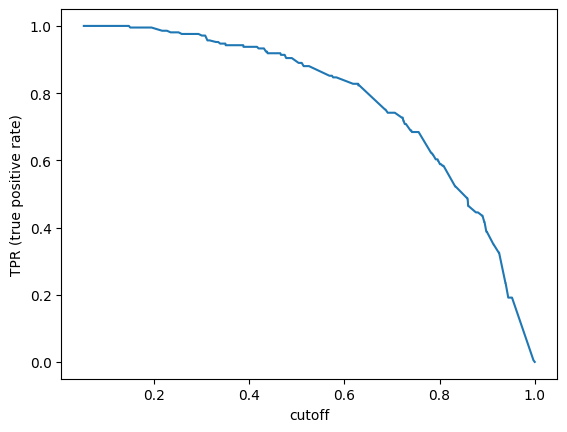

In [12]:
fpr, tpr, cutoffs = roc_curve(test.repay, test.pred)
cutoffs[0] = 1.0
plt.xlabel('cutoff')
plt.ylabel('TPR (true positive rate)')
plt.plot(cutoffs, tpr)
plt.show()

The first cutoff that still satisfies the 60% TPR requirement defines the upper end of the feasible range for this saved test sample.

In [13]:
all_cutoff = cutoffs[tpr >= 0.6][0]

In [14]:
all_cutoff

np.float64(0.7959765748336193)

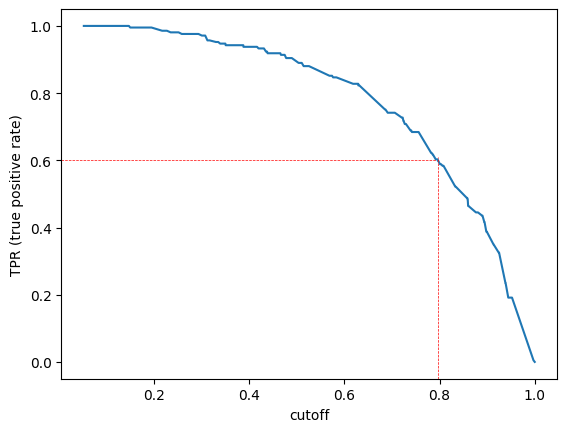

In [15]:
fpr, tpr, cutoffs = roc_curve(test.repay, test.pred)
cutoffs[0] = 1.0
plt.xlabel('cutoff')
plt.ylabel('TPR (true positive rate)')
plt.plot(cutoffs, tpr)
plt.axhline(y=0.6, xmax=0.95*all_cutoff, color='red', linestyle='--', lw=0.5)
plt.axvline(all_cutoff, ymax=0.6, color='red', linestyle='--', lw=0.5)
plt.show()

In [16]:
print(f"TPR is at least 60% for cutoffs in the range [0, {all_cutoff:.3f}]")

TPR is at least 60% for cutoffs in the range [0, 0.796]


Within the feasible range, the notebook chooses the highest cutoff because the false-positive rate falls as the threshold increases. This reflects a business trade-off: preserving the minimum opportunity target while reducing approvals among applicants who ultimately default.

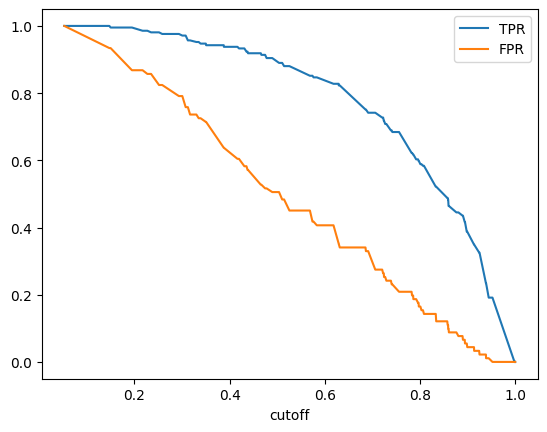

In [17]:
plt.xlabel('cutoff')
plt.plot(cutoffs, tpr, label='TPR')
plt.plot(cutoffs, fpr, label='FPR')
plt.legend()
plt.show()

The selected overall cutoff is approximately **0.796**. This is the strictest observed cutoff in the saved sample that keeps TPR at or above the 60% target.

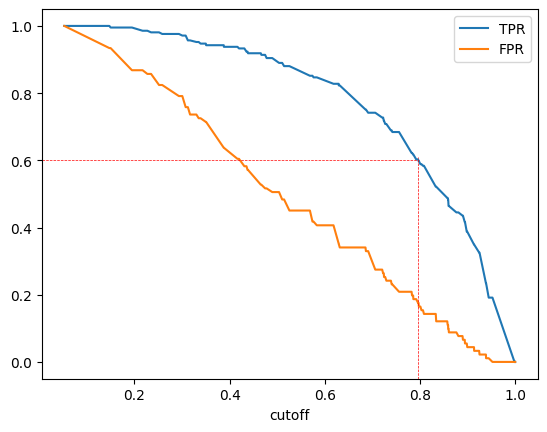

In [18]:
plt.xlabel('cutoff')
plt.plot(cutoffs, tpr, label='TPR')
plt.plot(cutoffs, fpr, label='FPR')
plt.axhline(y=0.6, xmax=0.95*all_cutoff, color='red', linestyle='--', lw=0.5)
plt.axvline(all_cutoff, ymax=0.6, color='red', linestyle='--', lw=0.5)
plt.legend()
plt.show()

The confusion-matrix rates make the operating consequences explicit. At the selected threshold, the saved notebook reports:

- **TPR:** 0.603
- **FNR:** 0.397
- **FPR:** 0.176
- **TNR:** 0.824

These rates matter more than a single accuracy value because they distinguish the two different kinds of lending error.

In [19]:
from sklearn.metrics import confusion_matrix
tnr, fpr, fnr, tpr  = confusion_matrix(test.repay, test.pred >= all_cutoff, normalize='true').ravel()

In [20]:
print(f"TPR = {tpr:.3f}, FNR = {fnr:.3f}, FPR = {fpr:.3f}, TNR = {tnr:.3f}")

TPR = 0.603, FNR = 0.397, FPR = 0.176, TNR = 0.824


Overall accuracy at this cutoff is **0.67**. That number is useful as a summary, but it does not answer the fairness question. The next step checks whether the errors and opportunities are distributed similarly across gender groups.

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
print(accuracy_score(test.repay, test.pred >= all_cutoff))

0.67


## Step 5 — Audit subgroup performance

The model did not use `Gender` as an input, but that does not establish fairness. The same overall threshold is now evaluated separately for female and male applicants.

The fairness question is specific: **Do applicants who repay receive the same opportunity to be classified positively across groups?**

At the common threshold, the saved results show a meaningful opportunity gap:

| Group | Accuracy | TPR | FNR | FPR | TNR |
|---|---:|---:|---:|---:|---:|
| Female | 0.65 | 0.57 | 0.43 | 0.18 | 0.82 |
| Male | 0.73 | 0.68 | 0.32 | 0.17 | 0.83 |

The false-positive rates are similar, but TPR differs by **11 percentage points**. In other words, the model reaches the overall 60% target while female applicants in this test sample fall below it and male applicants exceed it.

This is the central fairness finding of the notebook: excluding a protected attribute from training does not guarantee equal opportunity in the resulting decisions.

In [23]:
tnr, fpr, fnr, tpr  = confusion_matrix(test.repay[test.Gender=='Female'],
                                       test.pred[test.Gender=='Female'] >= all_cutoff,
                                       normalize='true').ravel()

In [24]:
acc = accuracy_score(test.repay[test.Gender=='Female'],
              test.pred[test.Gender=='Female'] >= all_cutoff)

In [25]:
print(f"""Metrics for Gender = Female:
Accuracy = {acc:.2f}
TPR = {tpr:.2f},
FNR = {fnr:.2f}, FPR = {fpr:.2f}, TNR = {tnr:.2f}""")

Metrics for Gender = Female: 
Accuracy = 0.65
TPR = 0.57, 
FNR = 0.43, FPR = 0.18, TNR = 0.82


In [26]:
tnr, fpr, fnr, tpr  = confusion_matrix(test.repay[test.Gender=='Male'],
                                       test.pred[test.Gender=='Male'] >= all_cutoff,
                                       normalize='true').ravel()

In [27]:
acc = accuracy_score(test.repay[test.Gender=='Male'],
              test.pred[test.Gender=='Male'] >= all_cutoff)

In [28]:
print(f"""Metrics for Gender = Male:
Accuracy = {acc:.2f}
TPR = {tpr:.2f},
FNR = {fnr:.2f}, FPR = {fpr:.2f}, TNR = {tnr:.2f}""")

Metrics for Gender = Male: 
Accuracy = 0.73
TPR = 0.68, 
FNR = 0.32, FPR = 0.17, TNR = 0.83


## Step 6 — Explore TPR equalization as a mitigation

The next experiment asks what would happen if each gender group used a cutoff selected to reach approximately the same minimum TPR target.

This is a useful technical demonstration of post-processing, not a recommendation for production lending. Applying different thresholds by a protected attribute can raise serious legal, compliance, and individual-fairness questions. Any real deployment would require jurisdiction-specific review.

The TPR-versus-cutoff curves are calculated separately for female and male applicants. Different score distributions mean the same threshold does not produce the same opportunity rate for both groups.

In [29]:
_, tpr_female, cutoffs_female = roc_curve(test.repay[test.Gender=='Female'], test.pred[test.Gender=='Female'])
cutoffs_female[0] = 1.0

In [30]:
_, tpr_male, cutoffs_male = roc_curve(test.repay[test.Gender=='Male'], test.pred[test.Gender=='Male'])
cutoffs_male[0] = 1.0

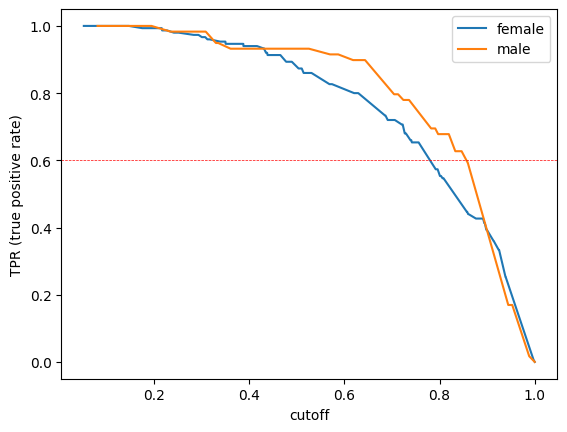

In [31]:
plt.xlabel('cutoff')
plt.ylabel('TPR (true positive rate)')
plt.plot(cutoffs_female, tpr_female, label='female')
plt.plot(cutoffs_male, tpr_male, label='male')
plt.axhline(y=0.6, color='red', linestyle='--', lw=0.5)
plt.legend()
plt.show()

The saved analysis finds different cutoffs for the two groups: approximately **0.76 for female applicants** and **0.85 for male applicants**. The lower female cutoff increases the share of repay-capable female applicants classified positively, while the higher male cutoff reduces that rate toward the same target.

In [32]:
female_cutoff = cutoffs_female[tpr_female >= 0.6][0]
male_cutoff = cutoffs_male[tpr_male >= 0.6][0]

In [33]:
print(f"The optimal cutoff for Gender=Female is {female_cutoff:.2f}")
print(f"The optimal cutoff for Gender=Male is {male_cutoff:.2f}")

The optimal cutoff for Gender=Female is 0.76
The optimal cutoff for Gender=Male is 0.85


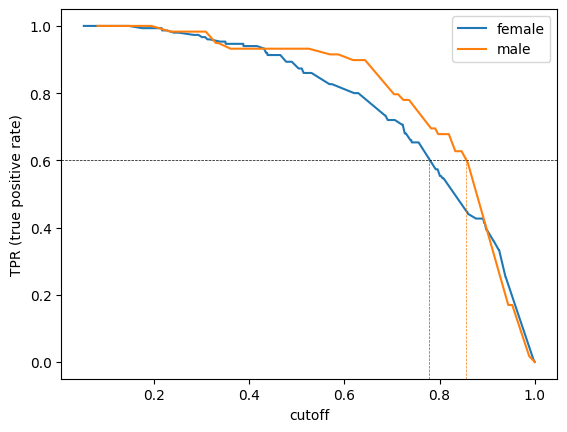

In [34]:
plt.xlabel('cutoff')
plt.ylabel('TPR (true positive rate)')
plt.plot(cutoffs_female, tpr_female, label='female')
plt.plot(cutoffs_male, tpr_male, label='male')
plt.axhline(y=0.6, color='black', linestyle='--', lw=0.5)
plt.axvline(1.03*female_cutoff, ymax=0.6, color='#1f77b4', linestyle='--', lw=0.5)
plt.axvline(1.01*male_cutoff, ymax=0.6, color='#ff7f0e', linestyle='--', lw=0.5)
plt.legend()
plt.show()

Because the sample is finite, the ROC curves move in steps rather than smoothly. A target such as exactly 0.60 TPR may therefore be unavailable at any observed threshold.

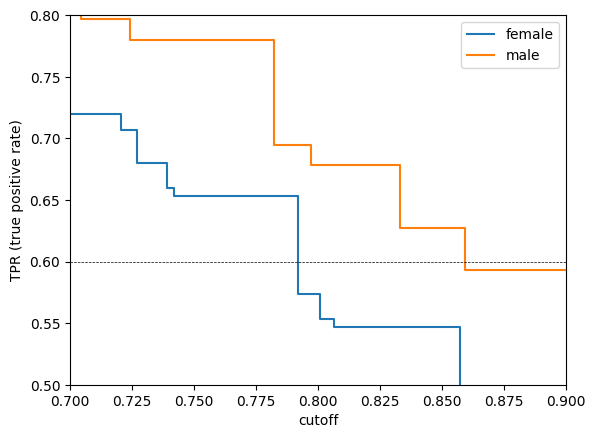

In [35]:
plt.xlabel('cutoff')
plt.ylabel('TPR (true positive rate)')
plt.xlim(left=0.70, right=0.90)
plt.ylim(bottom=0.5, top=0.8)
plt.plot(cutoffs_female, tpr_female, label='female', drawstyle='steps-pre')
plt.plot(cutoffs_male, tpr_male, label='male', drawstyle='steps-pre')
plt.axhline(y=0.6, color='black', linestyle='--', lw=0.5)
plt.legend()
plt.show()

For the female group, lowering the cutoff from the next higher observed value to 0.76 causes TPR to jump from roughly 0.57 to 0.65. The male curve has the same discrete behavior. This is why the post-processing result can only approximate the target on the saved sample.

## Step 7 — Evaluate the trade-offs after mitigation

Fairness interventions should be judged on the full error profile, not only the metric being optimized. After applying the group-specific cutoffs, the saved notebook reports:

| Group | Accuracy | TPR | FNR | FPR | TNR |
|---|---:|---:|---:|---:|---:|
| Female | 0.70 | 0.65 | 0.35 | 0.19 | 0.81 |
| Male | 0.73 | 0.63 | 0.37 | 0.07 | 0.93 |

The TPR gap narrows from **11 percentage points to 2**, but the FPR gap expands from about **1 percentage point to 12**. Equalizing one dimension of fairness therefore changes another dimension of risk.

In [36]:
tnr, fpr, fnr, tpr  = confusion_matrix(test.repay[test.Gender=='Female'],
                                       test.pred[test.Gender=='Female'] >= female_cutoff,
                                       normalize='true').ravel()
acc = accuracy_score(test.repay[test.Gender=='Female'],
              test.pred[test.Gender=='Female'] >= female_cutoff)

print(f"""Metrics for Gender = Female after TPR Equalization:
Accuracy = {acc:.2f}
TPR = {tpr:.2f},
FNR = {fnr:.2f}, FPR = {fpr:.2f}, TNR = {tnr:.2f}""")

Metrics for Gender = Female after TPR Equalization: 
Accuracy = 0.70
TPR = 0.65, 
FNR = 0.35, FPR = 0.19, TNR = 0.81


In [37]:
tnr, fpr, fnr, tpr  = confusion_matrix(test.repay[test.Gender=='Male'],
                                       test.pred[test.Gender=='Male'] >= male_cutoff,
                                       normalize='true').ravel()
acc = accuracy_score(test.repay[test.Gender=='Male'],
              test.pred[test.Gender=='Male'] >= male_cutoff)

print(f"""Metrics for Gender = Male after TPR Equalization:
Accuracy = {acc:.2f}
TPR = {tpr:.2f},
FNR = {fnr:.2f}, FPR = {fpr:.2f}, TNR = {tnr:.2f}""")

Metrics for Gender = Male after TPR Equalization: 
Accuracy = 0.73
TPR = 0.63, 
FNR = 0.37, FPR = 0.07, TNR = 0.93
